# DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING

In [ ]:
##importing libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
##importing datset

df = pd.read_csv("adult_with_headers (1).csv")
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Data Exploration

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,Capital_Total,Hours_Age_Ratio,capital_gain_log
count,32537.000000,32537.000000,3.253700e+04,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,3.094446,1.897808e+05,10.297507,10.081815,2.611427,6.139288,1.446538,1078.443741,87.368227,40.440329,36.419184,1165.811968,1.128274,0.735163
std,13.637984,1.107549,1.055565e+05,3.870142,2.571633,1.506301,3.973173,1.607064,7387.957424,403.101833,12.346889,6.053816,7386.200428,0.464747,2.455562
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.012195,0.000000
25%,28.000000,3.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,0.000000,0.000000,40.000000,38.000000,0.000000,0.816327,0.000000
50%,37.000000,3.000000,1.783560e+05,11.000000,10.000000,2.000000,6.000000,1.000000,0.000000,0.000000,40.000000,38.000000,0.000000,1.071429,0.000000
75%,48.000000,3.000000,2.369930e+05,12.000000,12.000000,4.000000,9.000000,3.000000,0.000000,0.000000,45.000000,38.000000,0.000000,1.406250,0.000000
max,90.000000,7.000000,1.484705e+06,15.000000,16.000000,6.000000,13.000000,5.000000,99999.000000,4356.000000,99.000000,40.000000,99999.000000,4.950000,11.512925


In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.replace(' ?', np.nan, inplace=True)

df.isnull().sum()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_4083/648574876.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
age,int64
workclass,int64
fnlwgt,int64
education,int64
education_num,int64
marital_status,int64
occupation,int64
relationship,int64
race,object
capital_gain,int64


In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(num_cols)
print(cat_cols)

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')
Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')


In [ ]:
standard_scaler = StandardScaler()

df_standard = df.copy()

df_standard[num_cols] = standard_scaler.fit_transform(df_standard[num_cols])

df_standard.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,-1.063569,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,0.148292,-0.216743,-0.035664,United-States,<=50K
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145975,-0.216743,-2.222483,United-States,<=50K
2,-0.042936,Private,0.245040,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
3,1.056950,Private,0.425752,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145975,-0.216743,-0.035664,United-States,<=50K
4,-0.776193,Private,1.408066,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145975,-0.216743,-0.035664,Cuba,<=50K


In [ ]:
minmax_scaler = MinMaxScaler()

df_minmax = df.copy()

df_minmax[num_cols] = minmax_scaler.fit_transform(df_minmax[num_cols])

df_minmax.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


## Comparison of Scaling Techniques

### Standard Scaling
Standard Scaling transforms data so that it has a mean of 0 and a standard deviation of 1.

**Preferred when:**
- Data follows a normal distribution.
- Algorithms are distance-based (KNN, SVM, PCA, Logistic Regression).
- Presence of outliers is acceptable.

### Min-Max Scaling
Min-Max Scaling transforms values to a fixed range, usually between 0 and 1.

**Preferred when:**
- Data does not follow a normal distribution.
- Features need to be bounded within a specific range.
- Algorithms such as Neural Networks benefit from normalized inputs.

### Conclusion
Standard Scaling is suitable for normally distributed data, whereas Min-Max Scaling is preferred when features need to be scaled to a fixed range.

In [ ]:
small_cat_cols = [col for col in cat_cols if df[col].nunique() < 5]

small_cat_cols

['sex', 'income']

In [ ]:
df = pd.get_dummies(df, columns=small_cat_cols)

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

large_cat_cols = [col for col in cat_cols if df[col].nunique() > 5]

large_cat_cols

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'native_country']

In [ ]:
le = LabelEncoder()

for col in large_cat_cols:
    df[col] = le.fit_transform(df[col])

###  Pros and Cons of One-Hot Encoding vs Label Encoding

| | **One-Hot Encoding** | **Label Encoding** |
|---|---|---|
| **What it does** | Creates a new binary column for each category | Assigns each category a single integer (0, 1, 2, ...) |
| **Pros** | No false ordinal relationship between categories; works well with linear models | Memory efficient — does not increase number of columns; simple and fast |
| **Cons** | Increases dimensionality significantly (curse of dimensionality) if categories are many | Introduces a fake order/rank between categories (e.g., model may assume one category > another, which is meaningless) |
| **Best suited for** | Low-cardinality nominal columns (e.g., `sex`, `race`) — no natural order | High-cardinality columns or tree-based models (Decision Tree, Random Forest, XGBoost) which can handle the encoded integers without assuming false order |
| **Risk** | Sparse, large matrix — slows down training on very high-cardinality columns | Misleading for linear/distance-based models since integers imply magnitude/order |

**Why we used this split rule (< 5 vs >= 5 categories):** One-Hot Encoding is safe and effective for columns with very few categories since it won't blow up the dataset's width. For columns with many categories (like `native_country` with ~40 categories), One-Hot Encoding would create 40 new columns — Label Encoding keeps the dataset compact, which works fine especially with tree-based models that don't assume ordinal relationships.

**Task 3: Feature Engineering**

In [ ]:
##feature1
df['Capital_Total'] = df['capital_gain'] + df['capital_loss']

### Feature 1: Capital_Total

Capital_Total is created by combining capital_gain and capital_loss.

Formula:

Capital_Total = capital_gain - capital_loss

**Rationale:**
- Provides the overall capital impact of an individual.
- Reduces the need for the model to interpret two separate but related variables.
- May improve prediction of income level.

In [ ]:
#feature2
df['Hours_Age_Ratio'] = df['hours_per_week'] / (df['age'] + 1)

### Feature 2: Hours_Age_Ratio

Hours_Age_Ratio = hours_per_week / age

**Rationale:**
- Represents work intensity relative to age.
- Helps identify individuals who work significantly more hours for their age group.
- May provide additional information useful for income prediction.

***Log Transformation***

In [ ]:
##checking skewness
df['capital_gain'].skew()

np.float64(11.949402833551463)

In [ ]:
#Applying Log Transformation
df['capital_gain_log'] = np.log1p(df['capital_gain'])

## Log Transformation of Skewed Feature

The feature capital_gain was highly right-skewed.

A log transformation using log1p() was applied:

log1p(x) = log(1 + x)

### Benefits
- Reduces skewness.
- Makes the distribution closer to normal.
- Improves the performance of many machine learning algorithms.
- Reduces the influence of extreme values.

The transformed feature is named capital_gain_log.

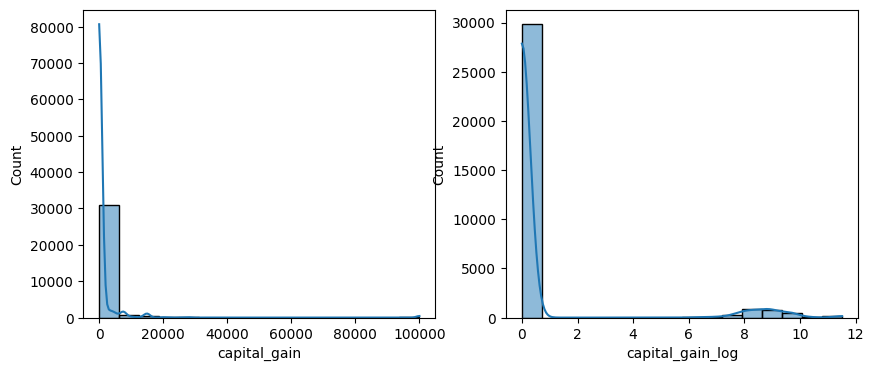

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['capital_gain'], kde=True)

plt.subplot(1,2,2)
sns.histplot(df['capital_gain_log'], kde=True)

plt.show()

*Justification*:  The capital-gain feature is highly right-skewed. Applying log transformation reduces skewness, minimizes the effect of extreme values, and improves the distribution of the data, making it more suitable for machine learning models.